# JointXpress on MNIST — direct joint training

This notebook follows the same training structure as `jointXpress.ipynb`:

- no autoencoder pretraining;
- the encoder, decoder, and latent generator are optimized together from epoch 1;
- landmarks and the Nyström cache are rebuilt from the current positive latent batch;
- the drift loss is applied to generated latents only, exactly as in the supplied objective.


In [11]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader

torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


transform = transforms.ToTensor()
train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


Using: cuda


In [12]:
def select_landmarks(y_pos, num_landmarks=128):
    num_landmarks = min(num_landmarks, y_pos.shape[0])
    indices = torch.randperm(y_pos.shape[0], device=y_pos.device)[:num_landmarks]
    return y_pos[indices]


def kzu(z, landmarks, T):
    return torch.exp(-torch.cdist(z, landmarks) / T)


def build_nystrom_cache(landmarks, T, jitter=1e-5):
    K_uu = kzu(landmarks, landmarks, T)
    K_uu = K_uu + jitter * torch.eye(len(landmarks), device=landmarks.device)
    eigenvalues, eigenvectors = torch.linalg.eigh(K_uu)
    eigenvalues = torch.clamp(eigenvalues, min=jitter)
    return eigenvectors @ torch.diag(torch.rsqrt(eigenvalues)) @ eigenvectors.T


def nystrom_map(z, landmarks, K_uu_inv_sqrt, T):
    # The eigendecomposition is cached outside the gradient calculation.
    return (kzu(z, landmarks, T) @ K_uu_inv_sqrt).T


def pre_compute_summaries(y_pos, landmarks, K_uu_inv_sqrt, T):
    phi_y = nystrom_map(y_pos, landmarks, K_uu_inv_sqrt, T)
    return phi_y @ y_pos, phi_y.sum(dim=1, keepdim=True)


def attraction(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    phi = nystrom_map(y_neg, landmarks, K_uu_inv_sqrt, T)
    numerator = (Ap.T @ phi).T
    denominator = phi.T @ bp + 1e-8
    return numerator / denominator


def repulsion(y_neg, T):
    N = y_neg.shape[0]
    dist_neg = torch.cdist(y_neg, y_neg)

    # Remove self-interaction.
    dist_neg = dist_neg + torch.eye(N, device=dist_neg.device) * 1e6
    K = torch.exp(-dist_neg / T)
    denominator = K.sum(dim=1, keepdim=True) + 1e-8
    return (K @ y_neg) / denominator


def compute_V(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T=1.0):
    V_pos = attraction(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T)
    V_neg = repulsion(y_neg, T)
    return V_pos - V_neg


def drift_loss(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    with torch.no_grad():
        V = compute_V(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T)
        frozen_targets = (generated + V).detach()
    return F.mse_loss(generated, frozen_targets, reduction="mean"), V


def recon_loss(y_pos_recon, y_pos):
    return F.mse_loss(y_pos_recon, y_pos, reduction="mean")


def kl_loss(mu, logvar):
    kl_per_sample = -0.5 * (
        1 + logvar - mu.pow(2) - logvar.exp()
    ).sum(dim=-1)
    return kl_per_sample.mean()


def variance_loss(mu, gamma=1.5, eps=1e-4):
    std = torch.sqrt(mu.var(dim=0, unbiased=True) + eps)
    return torch.mean(F.relu(gamma - std))


def covariance_loss(latents):
    batch_size, dim = latents.shape
    centered = latents - latents.mean(dim=0, keepdim=True)
    cov = (centered.T @ centered) / (batch_size - 1)
    off_diag = cov - torch.diag(torch.diag(cov))
    return off_diag.pow(2).sum() / dim


def total_loss(
    y_pos_recon, y_pos, y_pos_mu, y_pos_logvar,
    y_neg_latent, y_pos_latent, temp,
    landmarks, K_uu_inv_sqrt, Ap, bp,
    lambda_kl=0.01, lambda_drift=1.0,
    lambda_var=0.1, lambda_cov=0.1,
):
    L_recon = recon_loss(y_pos_recon, y_pos)
    L_kl = kl_loss(y_pos_mu, y_pos_logvar)
    L_drift, V = drift_loss(
        y_neg_latent, landmarks, K_uu_inv_sqrt, Ap, bp, temp
    )
    L_var = variance_loss(y_pos_mu) + variance_loss(y_neg_latent)
    L_cov = covariance_loss(y_pos_mu) + covariance_loss(y_neg_latent)

    total = (
        L_recon
        + lambda_kl * L_kl
        + lambda_drift * L_drift
        + lambda_var * L_var
        + lambda_cov * L_cov
    )
    loss_items = {
        "recon": L_recon.detach(),
        "kl": L_kl.detach(),
        "drift": L_drift.detach(),
        "V": V.detach(),
        "var": L_var.detach(),
        "covar": L_cov.detach(),
    }
    return total, loss_items


In [13]:
class MNISTJointXpress(nn.Module):
    def __init__(self, input_dim=784, latent_dim=16):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim

        # Slightly narrower than the original 256 -> 128 backbone.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192),
            nn.LeakyReLU(0.2),
            nn.Linear(192, 96),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96),
            nn.LeakyReLU(0.2),
            nn.Linear(96, 192),
            nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim),
            nn.Sigmoid(),
        )

        # Preserve the same generator depth while reducing its width.
        self.generator = nn.Sequential(
            nn.Linear(latent_dim, 48),
            nn.SiLU(),
            nn.Linear(48, 48),
            nn.SiLU(),
            nn.Linear(48, 48),
            nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def get_latent(self, y):
        features = self.encoder(y)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)
        latent = self.reparameterize(mu, logvar)
        return mu, logvar, latent

    def decode(self, z):
        return self.decoder(z)

    def generate(self, noise):
        # Noise is sampled directly in latent space, not passed through encoder.
        generated_latent = self.generator(noise)
        generated_final = self.decode(generated_latent)
        return generated_latent, generated_final


In [20]:
def training_loop(
    num_epochs, T, num_landmarks,
    lambda_kl, lambda_drift, lambda_var, lambda_cov,
    batch_size=1000, lr=1e-3,
):
    model = MNISTJointXpress(input_dim=784, latent_dim=LATENT_DIM).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)

    train_losses = []
    recon_losses = []
    kl_losses = []
    drift_losses = []
    var_losses = []
    covar_losses = []
    average_V = []
    evolution = []
    snapshot_epochs = set(range(0, num_epochs + 1, max(1, num_epochs // 5)))
    snapshot_epochs.add(num_epochs)

    print("Training started")
    start_time = time.perf_counter()

    for epoch in range(num_epochs + 1):
        model.train()
        epoch_items = {key: 0.0 for key in ("total", "recon", "kl", "drift", "var", "covar", "V")}
        last_pos = None
        last_neg = None

        for images, _ in train_loader:
            y_pos = images.to(device, non_blocking=True).flatten(start_dim=1)
            noise = torch.randn(y_pos.shape[0], model.latent_dim, device=device)

            mu, logvar, y_pos_latent = model.get_latent(y_pos)
            y_pos_recon = model.decode(y_pos_latent)
            y_neg_latent, y_neg_recon = model.generate(noise)

            # The drift target/cache is fixed for this optimization step.
            with torch.no_grad():
                latent_support = y_pos_latent.detach()
                landmarks = select_landmarks(latent_support, num_landmarks)
                K_uu_inv_sqrt = build_nystrom_cache(landmarks, T)
                Ap, bp = pre_compute_summaries(
                    latent_support, landmarks, K_uu_inv_sqrt, T
                )

            loss, loss_items = total_loss(
                y_pos_recon, y_pos, mu, logvar,
                y_neg_latent, y_pos_latent, T,
                landmarks, K_uu_inv_sqrt, Ap, bp,
                lambda_kl, lambda_drift, lambda_var, lambda_cov,
            )

            if not torch.isfinite(loss):
                raise FloatingPointError(f"Non-finite loss at epoch {epoch}: {loss.item()}")

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            epoch_items["total"] += loss.item()
            epoch_items["recon"] += loss_items["recon"].item()
            epoch_items["kl"] += loss_items["kl"].item()
            epoch_items["drift"] += loss_items["drift"].item()
            epoch_items["var"] += loss_items["var"].item()
            epoch_items["covar"] += loss_items["covar"].item()
            epoch_items["V"] += loss_items["V"].norm(dim=1).mean().item()
            last_pos = y_pos_latent.detach()
            last_neg = y_neg_latent.detach()

        num_batches = len(train_loader)
        for key in epoch_items:
            epoch_items[key] /= num_batches

        train_losses.append(epoch_items["total"])
        recon_losses.append(epoch_items["recon"])
        kl_losses.append(epoch_items["kl"])
        drift_losses.append(epoch_items["drift"])
        var_losses.append(epoch_items["var"])
        covar_losses.append(epoch_items["covar"])
        average_V.append(epoch_items["V"])

        if epoch in snapshot_epochs:
            evolution.append({
                "epoch": epoch,
                "pos": last_pos.cpu().numpy(),
                "neg": last_neg.cpu().numpy(),
            })

        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            total_value = epoch_items["total"]
            print(f"-------- Epoch {epoch} --------")
            print(f"total={total_value:.6f}")
            print(f"recon={epoch_items['recon']:.6f}")
            print(f"kl={epoch_items['kl']:.6f}    scaled={lambda_kl * epoch_items['kl']:.6f}")
            print(f"drift={epoch_items['drift']:.6f}    scaled={lambda_drift * epoch_items['drift']:.6f}")
            print(f"var={epoch_items['var']:.6f}    scaled={lambda_var * epoch_items['var']:.6f}")
            print(f"covar={epoch_items['covar']:.6f}    scaled={lambda_cov * epoch_items['covar']:.6f}")
            print(f"average |V|={epoch_items['V']:.6f}")
            print(f"latent std positive={last_pos.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    elapsed = (time.perf_counter() - start_time) / 60
    print(f"Finished. Training took {elapsed:.2f} minutes")
    return (
        model, train_losses, recon_losses, kl_losses,
        drift_losses, var_losses, covar_losses, average_V, evolution,
    )


In [27]:
LATENT_DIM = 64
BATCH_SIZE = 1000
NUM_EPOCHS = 500
NUM_LANDMARKS = 128
TEMPERATURE = 2

LAMBDA_KL = 1e-3
LAMBDA_DRIFT = 100.0
LAMBDA_VAR = 1.0
LAMBDA_COV = 1.0

f_trained, losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, evolution = training_loop(
    NUM_EPOCHS,
    TEMPERATURE,
    NUM_LANDMARKS,
    LAMBDA_KL,
    LAMBDA_DRIFT,
    LAMBDA_VAR,
    LAMBDA_COV,
    batch_size=BATCH_SIZE,
    lr=1e-3,
)


Training started
-------- Epoch 0 --------
total=9.921938
recon=0.100037
kl=8.466256    scaled=0.008466
drift=0.070854    scaled=7.085351
var=2.656943    scaled=2.656943
covar=0.071140    scaled=0.071140
average |V|=1.954674
latent std positive=1.061299
latent std negative=0.056954
-------- Epoch 1 --------
total=3.999587
recon=0.060170
kl=9.279748    scaled=0.009280
drift=0.013151    scaled=1.315105
var=2.508981    scaled=2.508981
covar=0.106051    scaled=0.106051
average |V|=0.896786
latent std positive=1.045847
latent std negative=0.047970
-------- Epoch 2 --------
total=3.739607
recon=0.050409
kl=12.658294    scaled=0.012658
drift=0.011424    scaled=1.142363
var=2.404737    scaled=2.404737
covar=0.129440    scaled=0.129440
average |V|=0.849923
latent std positive=1.045315
latent std negative=0.052128
-------- Epoch 3 --------
total=3.896748
recon=0.043154
kl=19.109232    scaled=0.019109
drift=0.014052    scaled=1.405240
var=2.289137    scaled=2.289137
covar=0.140107    scaled=0.140

KeyboardInterrupt: 

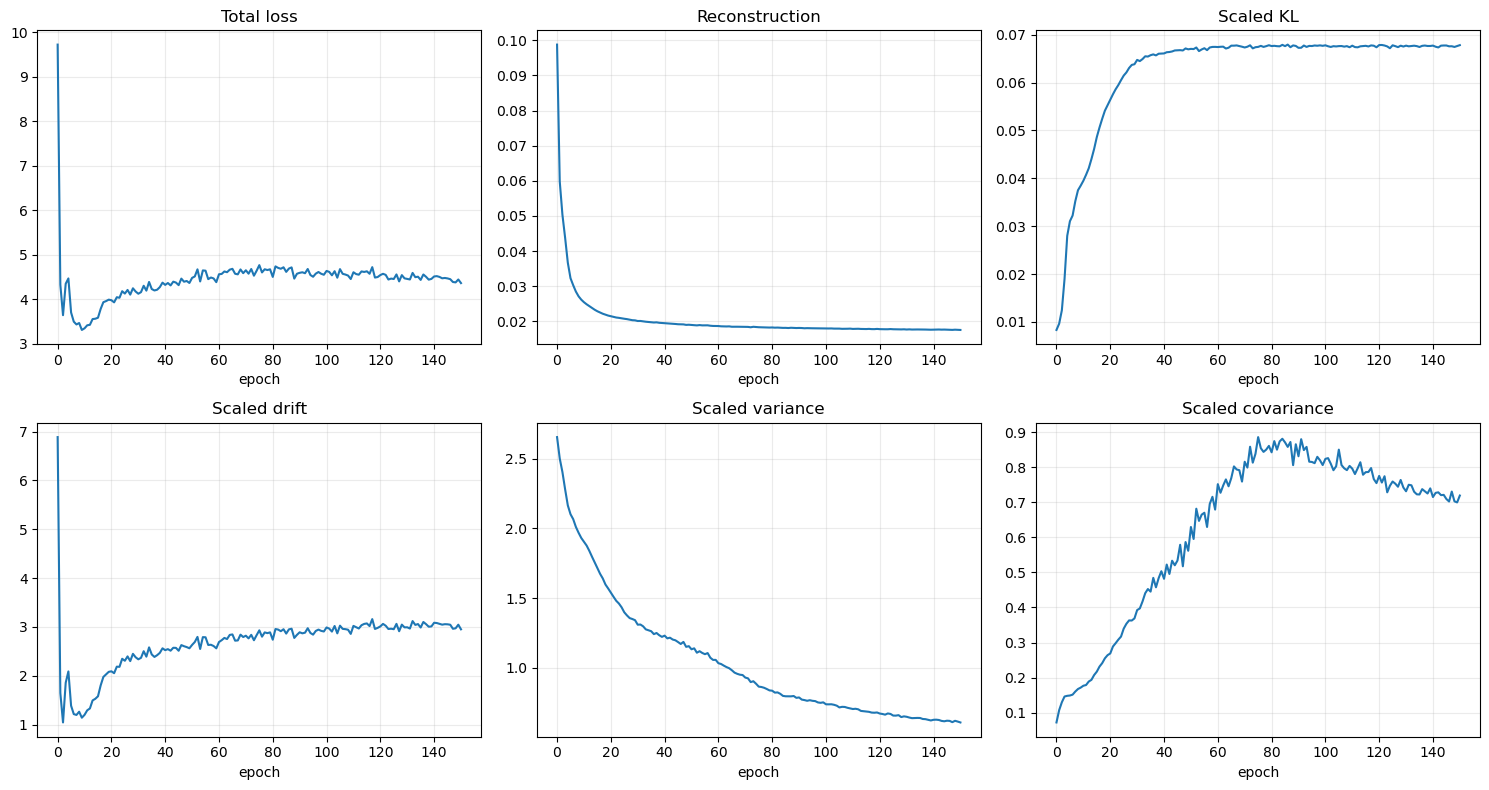

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
axes[0].plot(losses); axes[0].set_title("Total loss")
axes[1].plot(recon_losses); axes[1].set_title("Reconstruction")
axes[2].plot([LAMBDA_KL * x for x in kl_losses]); axes[2].set_title("Scaled KL")
axes[3].plot([LAMBDA_DRIFT * x for x in drift_losses]); axes[3].set_title("Scaled drift")
axes[4].plot([LAMBDA_VAR * x for x in var_losses]); axes[4].set_title("Scaled variance")
axes[5].plot([LAMBDA_COV * x for x in covar_losses]); axes[5].set_title("Scaled covariance")
for axis in axes:
    axis.set_xlabel("epoch")
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


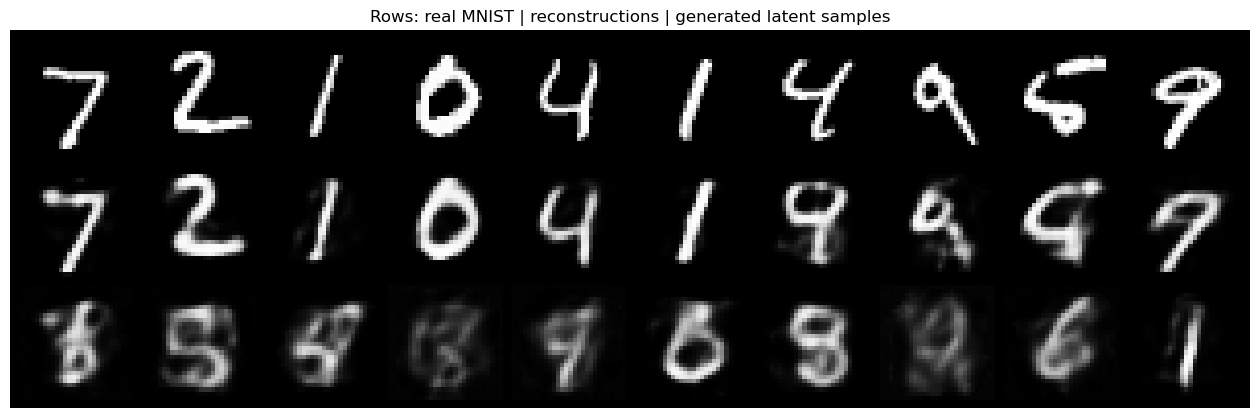

In [26]:
@torch.no_grad()
def show_mnist_results(model, samples=10):
    model.eval()
    images, labels = next(iter(test_loader))
    images = images[:samples].to(device).flatten(start_dim=1)
    _, _, z_pos = model.get_latent(images)
    reconstructions = model.decode(z_pos).view(-1, 1, 28, 28).cpu()

    noise = torch.randn(samples, model.latent_dim, device=device)
    _, generated = model.generate(noise)
    generated = generated.view(-1, 1, 28, 28).cpu()

    comparison = torch.cat([
        images.view(-1, 1, 28, 28).cpu(),
        reconstructions,
        generated,
    ])
    grid = utils.make_grid(comparison, nrow=samples, padding=2)
    plt.figure(figsize=(16, 5))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title("Rows: real MNIST | reconstructions | generated latent samples")
    plt.show()


show_mnist_results(f_trained)
